In [56]:
import pandas as pd
import os
from pathlib import Path
import numpy as np
#url = "https://erddap.dataexplorer.oceanobservatories.org/erddap/tabledap/ooi-ce09ospm-wfp01-04-flortk000.csv?time%2Cz%2Cmass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled%2Cmass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled_qc_agg&time%3E=2024-03-01"
#url = "https://erddap.dataexplorer.oceanobservatories.org/erddap/tabledap/ooi-ce09ospm-wfp01-04-flortk000.csv?time%2Clatitude%2Clongitude%2Cz%2Cmass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled%2Cmass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled_qc_agg&time%3E=2024-03-01&time%3C=2025-12-05T00%3A00%3A00Z&z%3E=-50"
url = "https://erddap.dataexplorer.oceanobservatories.org/erddap/tabledap/ooi-ce04osps-sf01b-3a-flortd104.csv?time%2Clatitude%2Clongitude%2Cz%2Cmass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled%2Cmass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled_qc_agg&time%3E=2024-03-01&time%3C=2025-12-05T00%3A00%3A00Z&z%3E=-200"
df = pd.read_csv(url, skiprows=[1])
out_dir = Path("_temp_data")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "endurance_profiles_ooi-ce09ospm-wfp01-04-flortk000.parquet"
#new.to_parquet(out_path, index=False)
# Depth (positive down)
df["depth"] = -df["z"]
    
    # Filter 0–200 m (add QC back if you want)
mask = (df["depth"] >= 0) & (df["depth"] < 200)
    # & (df[qc_col] == 1.0)
df_good = df[mask].copy()
df_good

,time,latitude,longitude,z,mass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled,mass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled_qc_agg,depth
0,2024-03-01T00:00:00Z,44.369353,-124.954108,-161.0,0.033150,1,161.0
1,2024-03-01T00:01:00Z,44.369353,-124.954108,-161.0,0.030857,1,161.0
2,2024-03-01T00:02:00Z,44.369353,-124.954108,-161.0,0.037528,1,161.0
3,2024-03-01T00:03:00Z,44.369353,-124.954108,-161.0,0.038779,1,161.0
4,2024-03-01T00:04:00Z,44.369353,-124.954108,-161.0,0.022100,1,161.0
...,...,...,...,...,...,...,...
2346867,2025-12-04T03:33:00Z,44.369353,-124.954108,-51.0,0.205295,1,51.0
2346868,2025-12-04T03:33:00Z,44.369353,-124.954108,-50.0,0.211731,1,50.0
2346869,2025-12-04T03:33:00Z,44.369353,-124.954108,-49.0,0.210312,1,49.0
2346870,2025-12-04T03:34:00Z,44.369353,-124.954108,-49.0,0.231840,1,49.0


In [57]:
df_good.depth.max()

np.float64(199.0)

In [49]:
import pandas as pd
import os
from pathlib import Path
import numpy as np
url = "https://erddap.dataexplorer.oceanobservatories.org/erddap/tabledap/ooi-ce04osps-sf01b-3a-flortd104.csv?time%2Clatitude%2Clongitude%2Cz%2Cmass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled%2Cmass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled_qc_agg&time%3E=2024-03-01&time%3C=2025-12-05T00%3A00%3A00Z&z%3E=-50"
new = pd.read_csv(url, skiprows=[1])
out_dir = Path("_temp_data")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "endurance_profiles_ooi-ce04osps-sf01b-3a-flortd104.parquet"
#new.to_parquet(out_path, index=False)
#url = "https://erddap.dataexplorer.oceanobservatories.org/erddap/tabledap/ooi-ce04osps-sf01b-3a-flortd104.das?z%2Cmass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled%2Cmass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled_qc_agg&time%3E=2025-11-28T00%3A00%3A00Z&time%3C=2025-12-05T00%3A00%3A00Z&z%3E=-50"
new

,time,latitude,longitude,z,mass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled,mass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled_qc_agg
0,2024-08-22T21:35:00Z,44.369353,-124.954108,-50.0,0.410395,1
1,2024-08-22T21:35:00Z,44.369353,-124.954108,-49.0,0.443460,1
2,2024-08-22T21:36:00Z,44.369353,-124.954108,-49.0,0.455130,1
3,2024-08-22T21:36:00Z,44.369353,-124.954108,-48.0,0.495327,1
4,2024-08-22T21:36:00Z,44.369353,-124.954108,-47.0,0.546059,1
...,...,...,...,...,...,...
461136,2025-12-04T01:41:00Z,44.369353,-124.954108,-47.0,0.208035,1
461137,2025-12-04T03:33:00Z,44.369353,-124.954108,-50.0,0.211731,1
461138,2025-12-04T03:33:00Z,44.369353,-124.954108,-49.0,0.210312,1
461139,2025-12-04T03:34:00Z,44.369353,-124.954108,-49.0,0.231840,1


In [82]:
import numpy as np
import pandas as pd
from pathlib import Path
from urllib.parse import urlparse
import os

def ooi_mooring_save_file(url, description=None, id=None, save=False, out_dir=Path("_temp_data/ooi")):

    df = pd.read_csv(url, skiprows=[1])

    if id == "ooi-ce04ossm-rid27-02-flortd000":
        chl_var = "mass_concentration_of_chlorophyll_a_in_sea_water"
    else:
        chl_var = "mass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled"
    
    # Rename CHLA columns
    df = df.rename(columns={
        chl_var: "CHLA",
    })
    
    chla_col = "CHLA"
    
    # Time + date
    df["time"] = pd.to_datetime(df["time"])
    df["date"] = df["time"].dt.floor("D")
    
    # Depth (positive down)
    df["depth"] = -df["z"]
    
    # Filter 0–200 m (add QC back if you want)
    mask = (df["depth"] >= 0) & (df["depth"] < 200)
    df_good = df[mask].copy()
    
    # 10 m bins
    bins = np.arange(0, 210, 10)  # 0,10,...,200
    labels = [f"{b}-{b+10}" for b in bins[:-1]]
    
    df_good["depth_bin"] = pd.cut(
        df_good["depth"],
        bins=bins,
        labels=labels,
        right=False,
    )
    
    # ---- PER-DAY × DEPTH-BIN AGGREGATION (with lat/lon) ----
    grp = (
        df_good
        .groupby(["date", "depth_bin"], observed=True)
        .agg(
            lat=("latitude", "first"),
            lon=("longitude", "first"),
            chla=(chla_col, "mean"),
        )
        .reset_index()
    )
    
    # ---- PIVOT TO WIDE FORM ----
    wide = grp.pivot(
        index=["date", "lat", "lon"],
        columns="depth_bin",
        values="chla",
    ).reset_index()
    
    # Rename depth-bin columns "0-10" → "chla_0_10"
    wide.columns = [
        ("chla_" + str(c).replace("-", "_")) if c not in ("date", "lat", "lon") else c
        for c in wide.columns
    ]
    
    # rename date → time
    wide = wide.rename(columns={"date": "time"})

    if description is not None:
        wide["description"]=description

    if save:
        parsed = urlparse(url)
        path = parsed.path
        filename = os.path.basename(path)         # 'ooi-ce04osps-sf01b-3a-flortd104.csv'
        dataset_id = filename.split('.')[0]       # 'ooi-ce04osps-sf01b-3a-flortd104'
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = f"{out_dir}/{dataset_id}.parquet"
        wide.to_parquet(out_path)
        return wide, out_path
    
    return wide, None

In [84]:
#%%script false --no-raise-error
from pathlib import Path

out_dir = Path("_temp_data/ooi")
out_dir.mkdir(parents=True, exist_ok=True)

for dataset_id, desc in endurance_dict.items():
    # choose chlorophyll variable name
    if dataset_id == "ooi-ce04ossm-rid27-02-flortd000":
        chl_var = "mass_concentration_of_chlorophyll_a_in_sea_water"
    else:
        chl_var = "mass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled"

    # expected parquet path for this dataset
    out_path = out_dir / f"{dataset_id}.parquet"

    # skip if file already exists
    if out_path.exists():
        print(f"Skipping {dataset_id}: {out_path} already exists")
        continue

    # build URL (special case without qc_agg)
    if dataset_id == "ooi-ce02shsp-sp002-07-flortj000":
        continue
    else:
        url = (
            "https://erddap.dataexplorer.oceanobservatories.org/erddap/tabledap/"
            f"{dataset_id}.csv?"
            "time%2Clatitude%2Clongitude%2Cz%2C"
            f"{chl_var}%2C"
            f"{chl_var}_qc_agg"
            "&time%3E=2024-03-01"
            "&time%3C=2025-12-05T00%3A00%3A00Z"
            "&z%3E=-200"
        )

    df, saved_path = ooi_mooring_save_file(
        url,
        description=desc,
        id=dataset_id,
        save=True,
        out_dir=out_dir,
    )
    print(f"Saved {dataset_id} ({desc}) to {saved_path}")



Skipping ooi-ce04ossm-rid27-02-flortd000: _temp_data/ooi/ooi-ce04ossm-rid27-02-flortd000.parquet already exists
Skipping ooi-ce04osps-sf01b-3a-flortd104: _temp_data/ooi/ooi-ce04osps-sf01b-3a-flortd104.parquet already exists
Skipping ooi-ce09ospm-wfp01-04-flortk000: _temp_data/ooi/ooi-ce09ospm-wfp01-04-flortk000.parquet already exists
Skipping ooi-ce01issp-sp001-08-flortj000: _temp_data/ooi/ooi-ce01issp-sp001-08-flortj000.parquet already exists
Skipping ooi-ce04ospd-dp01b-04-flntua103: _temp_data/ooi/ooi-ce04ospd-dp01b-04-flntua103.parquet already exists
Skipping ooi-ce02shsp-sp001-07-flortj000: _temp_data/ooi/ooi-ce02shsp-sp001-07-flortj000.parquet already exists
Saved ooi-ce06issp-sp001-08-flortj000 (Coastal Endurance: Washington Inshore Surface Piercing Profiler Mooring: Surface Piercing Profiler: 3-Wavelength Fluorometer) to _temp_data/ooi/ooi-ce06issp-sp001-08-flortj000.parquet
Saved ooi-ce07shsp-sp001-07-flortj000 (Coastal Endurance: Washington Shelf Surface Piercing Profiler Moor

In [85]:
df

,time,lat,lon,chla_0_10,chla_10_20,chla_20_30,chla_30_40,chla_40_50,chla_50_60,chla_60_70,chla_70_80,chla_80_90,description
0,2024-04-02 00:00:00+00:00,46.98805,-124.56633,1.403106,3.541384,2.426261,0.862566,0.321640,0.246619,0.232582,0.232171,0.246453,Coastal Endurance: Washington Shelf Surface Pi...
1,2024-04-03 00:00:00+00:00,46.98805,-124.56633,1.268236,1.493872,1.535100,0.643237,0.518450,0.396618,0.263785,0.173175,0.211345,Coastal Endurance: Washington Shelf Surface Pi...
2,2024-04-07 00:00:00+00:00,46.98805,-124.56633,0.516092,1.085928,2.160724,0.845409,0.650461,0.439059,0.404343,0.344745,0.421830,Coastal Endurance: Washington Shelf Surface Pi...
3,2024-04-08 00:00:00+00:00,46.98805,-124.56633,0.635923,1.868024,0.256151,0.242077,0.228559,0.181202,0.151230,0.238793,0.337636,Coastal Endurance: Washington Shelf Surface Pi...
4,2024-04-09 00:00:00+00:00,46.98805,-124.56633,0.467654,3.283970,0.840246,0.308525,0.268802,0.175483,0.146414,0.306199,0.583080,Coastal Endurance: Washington Shelf Surface Pi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,2024-07-09 00:00:00+00:00,46.98805,-124.56633,15.490878,5.840592,0.309201,0.335225,0.349675,0.440030,0.547771,0.746462,0.918242,Coastal Endurance: Washington Shelf Surface Pi...
59,2024-07-11 00:00:00+00:00,46.98805,-124.56633,4.497526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Coastal Endurance: Washington Shelf Surface Pi...
60,2024-07-12 00:00:00+00:00,46.98805,-124.56633,22.604809,14.422224,2.384997,1.209309,0.991621,0.612907,0.313735,0.403176,0.314223,Coastal Endurance: Washington Shelf Surface Pi...
61,2024-07-13 00:00:00+00:00,46.98805,-124.56633,16.365699,20.035522,15.982298,4.280086,2.379047,1.411592,1.475896,2.589436,3.888609,Coastal Endurance: Washington Shelf Surface Pi...


In [81]:
import pandas as pd

base = "https://erddap.dataexplorer.oceanobservatories.org/erddap/tabledap"
dataset_id = "ooi-ce02shsp-sp002-07-flortj000"

header_url = f"{base}/{dataset_id}.csv?"

# read only the header, skip the units row
df0 = pd.read_csv(header_url, skiprows=[1], nrows=0)
print(df0.columns)

Index(['time', 'latitude', 'longitude', 'z', 'cdomflo_profiler_depth_enabled',
       'mass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled',
       'flubsct_profiler_depth_enabled',
       'sea_water_practical_salinity_profiler_depth_enabled',
       'sea_water_pressure_profiler_depth_enabled',
       'sea_water_temperature_profiler_depth_enabled', 'station'],
      dtype='object')


In [28]:
df = pd.read_parquet(out_path)
df

,time,latitude,longitude,z,mass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled,mass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled_qc_agg
0,2024-08-22T21:35:00Z,44.369353,-124.954108,-50.0,0.410395,1
1,2024-08-22T21:35:00Z,44.369353,-124.954108,-49.0,0.443460,1
2,2024-08-22T21:36:00Z,44.369353,-124.954108,-49.0,0.455130,1
3,2024-08-22T21:36:00Z,44.369353,-124.954108,-48.0,0.495327,1
4,2024-08-22T21:36:00Z,44.369353,-124.954108,-47.0,0.546059,1
...,...,...,...,...,...,...
461136,2025-12-04T01:41:00Z,44.369353,-124.954108,-47.0,0.208035,1
461137,2025-12-04T03:33:00Z,44.369353,-124.954108,-50.0,0.211731,1
461138,2025-12-04T03:33:00Z,44.369353,-124.954108,-49.0,0.210312,1
461139,2025-12-04T03:34:00Z,44.369353,-124.954108,-49.0,0.231840,1


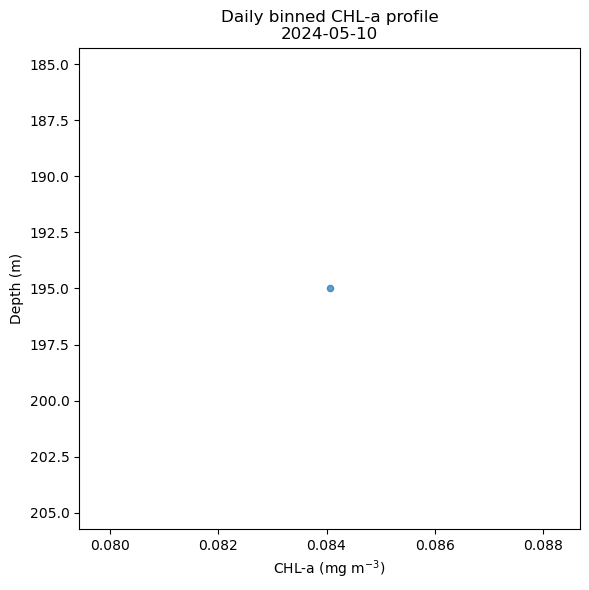

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# pick your day
day = pd.Timestamp("2024-05-10", tz="UTC")   # tz-aware

# subset to that day
subset = grp[grp["date"] == day].copy()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(subset["chla"], subset["depth_mid"], s=20, alpha=0.7)

ax.invert_yaxis()   # surface at top
ax.set_xlabel("CHL-a (mg m$^{-3}$)")
ax.set_ylabel("Depth (m)")
ax.set_title(f"Daily binned CHL-a profile\n{day.date()}")

plt.tight_layout()
plt.show()


In [25]:
new.time.min()

'2024-08-22T21:35:00Z'

In [18]:
import xarray as xr
url="https://erddap.dataexplorer.oceanobservatories.org/erddap/tabledap/ooi-ce04osps-sf01b-3a-flortd104.nc?z%2Cmass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled%2Cmass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled_qc_agg&time%3E=2025-11-28T00%3A00%3A00Z&time%3C=2025-12-05T00%3A00%3A00Z&z%3E=-50"
ds = xr.open_dataset(url)

OSError: [Errno -75] NetCDF: Malformed or unexpected Constraint: 'https://erddap.dataexplorer.oceanobservatories.org/erddap/tabledap/ooi-ce04osps-sf01b-3a-flortd104.nc?z%2Cmass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled%2Cmass_concentration_of_chlorophyll_a_in_sea_water_profiler_depth_enabled_qc_agg&time%3E=2025-11-28T00%3A00%3A00Z&time%3C=2025-12-05T00%3A00%3A00Z&z%3E=-50'